#### Identifying coral reef 'bright spots' from the global 2015-2017 thermal-stress event (Coral Reef Brightspots)
The BCO-DMO Global Bleaching & Environmental Dataset hosted by the Biological and Chemical Oceanography Data Management Office (BCO-DMO) compiles global coral bleaching observations from 1980 to 2020 with 62 different features such as site exposure, temperature, bleaching level, and more. The data is collected from seven sources: Reef Check, Donner et al. (2017), McClanahan et al. (2019), AGRRA (https://www.agrra.org), FRRP (https://ocean.floridamarine.org/FRRP/Home/Reports), Safaie et al. (2018), and Kumagai et al. (2018). This dataset can be used to include features that can predict reef health based on environmental events.

Dataset link: https://www.bco-dmo.org/dataset/773466

#### Dataset has already undergone the following preprocessing :
- renamed "Latitude Degrees" to "Latitude_Degrees"
- replaced blanks (no data) with "nd"
- removed special characters from place names
- added "Date2" column with date formatted as yyyymmdd
- created "Date" field from separate year, month, day columns
- removed commas from: "Ecoregion", "City_Town_Name", "Site_Name"
- replaced commas with semi-colons in: "Sample_Comments", "Site_Comments"
- replaced or removed line breaks (\n, \r,
) and tabs (\t) with spaces in: "Sample_Comments", "Site_Comments"
- replaced or removed non-printing characters
- reordered fields (moved comments to the end for readability)
- rounded latitude, longitude, and turbidity columns to 4 decimal places
- rounded all other numeric columns to 2 decimal places

In [1]:
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import metrics

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                                 ConfusionMatrixDisplay, precision_recall_fscore_support)

2026-04-10 18:06:45.601757: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 18:06:45.602008: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 18:06:45.638427: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-10 18:06:46.531724: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
# Load dataset, check shape, head
df = pd.read_csv("global_bleaching_environmental.csv")
print(df.shape)
df.head()

(41361, 62)


/tmp/ipykernel_21907/2690066894.py:2: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("global_bleaching_environmental.csv")


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [3]:
df.rename(columns=str.lower, inplace=True)
df.columns

Index(['site_id', 'sample_id', 'data_source', 'latitude_degrees',
       'longitude_degrees', 'ocean_name', 'reef_id', 'realm_name',
       'ecoregion_name', 'country_name', 'state_island_province_name',
       'city_town_name', 'site_name', 'distance_to_shore', 'exposure',
       'turbidity', 'cyclone_frequency', 'date_day', 'date_month', 'date_year',
       'depth_m', 'substrate_name', 'percent_cover', 'bleaching_level',
       'percent_bleaching', 'climsst', 'temperature_kelvin',
       'temperature_mean', 'temperature_minimum', 'temperature_maximum',
       'temperature_kelvin_standard_deviation', 'windspeed', 'ssta',
       'ssta_standard_deviation', 'ssta_mean', 'ssta_minimum', 'ssta_maximum',
       'ssta_frequency', 'ssta_frequency_standard_deviation',
       'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw',
       'ssta_dhw_standard_deviation', 'ssta_dhwmax', 'ssta_dhwmean', 'tsa',
       'tsa_standard_deviation', 'tsa_minimum', 'tsa_maximum', 'tsa_mean',
       'tsa_freq

#### Data Dictionary:
These data were collected from 7 sources and include information on the presence and absence of coral bleaching. Analysis were done on site exposure, distance to land, mean turbidity, cyclone frequency, and a suite of sea-surface temperature metrics at the times of survey.<br>

Looking at the data dictionary, there are 21 unitless columns. Its important to determine which of these are important for the regression or classification task.

In [4]:
data_dict = pd.read_csv("coral_data_dict.csv")
data_dict

,Supplied Name,Supplied Description,Supplied Units,Standard Name
0,Site_ID,Unique identifier for each site,unitless,site
1,Sample_ID,Unique identifier for each sampling event,unitless,sample
2,Data_Source,Source of data set,unitless,sampling_method
3,Latitude_Degrees,Latitude coordinates (positive vaues = North; ...,degrees North,latitude
4,Longitude_Degrees,Longitude coordinates (positive values = East;...,degrees East,longitude
...,...,...,...,...
57,TSA_DHWMean,The mean TSA_DHW over the entire time period,weeks,time_elapsed
58,Date,date of sampling event in format YYYY-MM-DD,%Y-%m-%d,date
59,Site_Comments,comments of any issues with the site or additi...,unitless,comment
60,Sample_Comments,comments of any issue or additional informatio...,unitless,comment


In [5]:
print(data_dict['Supplied Units'].value_counts())
data_dict.loc[data_dict["Supplied Units"].str.lower() == "unitless"]

Supplied Units
unitless                   21
degrees Celsius            14
weeks                       8
TSA per time period         4
SSTA per time period        4
percent                     2
Kelvin                      2
meters (m)                  2
degrees North               1
reciprocal meters (m-1)     1
degrees East                1
meters per hour             1
%Y-%m-%d                    1
Name: count, dtype: int64


,Supplied Name,Supplied Description,Supplied Units,Standard Name
0,Site_ID,Unique identifier for each site,unitless,site
1,Sample_ID,Unique identifier for each sampling event,unitless,sample
2,Data_Source,Source of data set,unitless,sampling_method
5,Ocean_Name,The ocean in which the sampling took place,unitless,region
6,Reef_ID,Unique identifier from Reef Check data,unitless,Site_ID
7,Realm_Name,Identification of realm as defined by the Mari...,unitless,region
8,Ecoregion_Name,Identification of the Ecoregions (150) as defi...,unitless,region
9,Country_Name,The country where sampling took place,unitless,region
10,State_Island_Province_Name,"The state, territory (e.g., Guam) or island gr...",unitless,region
11,City_Town_Name,"The region, city, or nearest town, where sampl...",unitless,region



Upon visual inspection of the unitless columns, the site_id, sample_id, reef_id, site_name, site_comments, sample_comments, bleaching_comments can be dropped, as they're unique and have no predictive power; the comments are unstructured text.

Geographic categorical variables, like Ocean_name, Realm_name, ecoregion_name, country_name, etc can be dropped as well, due to high cardinality and redundancy with latitude and longitude, which already capture spatial variation.

bleaching_level looks like being similar to the target variable and should be dropped.

Categorical columns to keep: exposure, cyclone frequency, substrate_name, date columns.

In [6]:
# Drop unwanted unitless columns:

cols_to_drop = ['site_id', 'sample_id', 'data_source', 'ocean_name', 'reef_id', 'realm_name',
       'ecoregion_name', 'country_name', 'state_island_province_name', 'city_town_name', 'site_name',
        'bleaching_level', 'site_comments', 'sample_comments', 'bleaching_comments']

df = df.drop(columns=cols_to_drop)
print(df.shape)

(41361, 47)


We have 47 columns remaining. <br>
First we will inspect nan's and drop columns with more than say 30% missing values
Then we will identify the numeric columns from the data dictionary which are not useful as features and drop those.

In [7]:
# Replace 'nd' (no data) with nan's, since all the missing values are labelled as 'nd' in the dataset
df = df.replace("nd", np.nan)
missing_values = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_values/ len(df)) *100
missing_summary = pd.DataFrame(
    {'missing_count': missing_values,
    'missing_percent': missing_percent}
    ).sort_values(by='missing_percent', ascending=False)

missing_summary.head()

,missing_count,missing_percent
substrate_name,12668,30.627886
percent_cover,12455,30.112908
percent_bleaching,6846,16.551824
depth_m,1799,4.349508
ssta_minimum,176,0.425522


substrate_name and percent_cover have 30% nan's, but substrate is a categorical variable (e.g., coral, rock, sand, etc.) and percent_cover is likely a numeric variable- ecological metric. So I'll keep these for now.

- percent_cover : measures how much substrate space a species occupies. It's about relative abundance of organisms on the reef floor. But its different from percent_bleaching. E.g. A reef could have 80% coral cover (lots of coral) 30% bleaching (30% of that coral is bleached). So, they're independent measurements.
- substrate_name -type of substrate from Reef Check data. Hard Coral, Nutrient Indicator Algae, Fleshy Seaweed.
- bleaching_level is not useful for imputation, it's just a site-level descriptor with one value.
- percent_bleaching - is an average of four transect segments (Reef Check) or average of a bleaching code. Need to check the data collection method for precent_bleaching.

In [8]:
# Check the units which have degrees in them
data_dict.loc[data_dict["Supplied Units"].str.lower().str.contains("degrees")]

,Supplied Name,Supplied Description,Supplied Units,Standard Name
3,Latitude_Degrees,Latitude coordinates (positive vaues = North; ...,degrees North,latitude
4,Longitude_Degrees,Longitude coordinates (positive values = East;...,degrees East,longitude
25,ClimSST,Climatological sea surface temperature (SST) b...,degrees Celsius,temp_ss
27,Temperature_Mean,Mean Temperature,degrees Celsius,temperature
28,Temperature_Minimum,Minimum Temperture,degrees Celsius,temperature
29,Temperature_Maximum,Maximum Temperature,degrees Celsius,temperature
32,SSTA,Sea Surface Temperature Anomaly: weekly SST mi...,degrees Celsius,temp_ss
33,SSTA_Standard_Deviation,The Standard Deviation of weekly SST Anomalies...,degrees Celsius,temp_ss
34,SSTA_Mean,The mean SSTA over the entire time period,degrees Celsius,temp_ss
35,SSTA_Minimum,The minimum SSTA over the entire time period,degrees Celsius,temp_ss


- Keep the lat and long columns.  
- ClimSST - The climatological baseline SST. Essential for checking relative stress.
- We can keep the temperature_mean as it represents the central tendency, but if its correlated with ClimSST, we can drop later. 
- temperature_maximum shows absolute extremes and capture acute stress events, we can keep this and drop temperature_minimum.
- Out of the SSTA (sea surface temp anomaly) we can keep SSTA, SSTA_std_dev and SSTA max.
- drop ssta mean and tsa mean.
- drop ssta_min and tsa_min as cool anomalies don’t cause bleaching.
- out of the TSA (thermal stress anomaly) we can keep TSA, TSA std dev and TSA max, but check collinearity with SSTA and drop later.
- drop day, month and year columns as date column has it already, so redundant with date
- Kelvin units: temperature_kelvin, temperature_kelvin_standard_deviation. Same info as Celsius columns.

In [9]:
# df.columns
# Drop temperature and date parts columns
temp_cols_to_drop = ['date_day', 'date_month', 'date_year', 'temperature_kelvin', 'temperature_minimum', 
                     'temperature_kelvin_standard_deviation', 'ssta_mean', 'ssta_minimum', 'tsa_minimum', 
                     'tsa_mean']

df = df.drop(columns=temp_cols_to_drop)

In [10]:
df.head()

,latitude_degrees,longitude_degrees,distance_to_shore,exposure,turbidity,cyclone_frequency,depth_m,substrate_name,percent_cover,percent_bleaching,...,tsa_maximum,tsa_frequency,tsa_frequency_standard_deviation,tsa_frequencymax,tsa_frequencymean,tsa_dhw,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean,date
0,23.163,-82.5260,8519.23,Exposed,0.0287,49.90,10,NaN,NaN,50.2,...,1.83,0,1.09,5,0,0,0.74,7.25,0.18,2005-09-15
1,-17.575,-149.7833,1431.62,Exposed,0.0262,51.20,14,NaN,NaN,50.7,...,3.00,0.25,0.93,4,0,0.26,0.67,4.65,0.19,1991-03-15
2,18.369,-64.5640,182.33,Exposed,0.0429,61.52,7,NaN,NaN,50.9,...,2.31,7,1.31,7,0,0,1.04,11.66,0.26,2006-01-15
3,17.760,-64.5680,313.13,Exposed,0.0424,65.39,9.02,NaN,NaN,50.9,...,2.19,3,0.94,4,0,0,0.75,5.64,0.2,2006-04-15
4,17.769,-64.5830,792.0,Exposed,0.0424,65.39,12.50,NaN,NaN,50.9,...,1.87,3,1.33,5,0,0,0.92,6.89,0.25,2006-04-15


In [11]:
# data type check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude_degrees                   41361 non-null  float64
 1   longitude_degrees                  41361 non-null  float64
 2   distance_to_shore                  41359 non-null  object 
 3   exposure                           41361 non-null  object 
 4   turbidity                          41355 non-null  object 
 5   cyclone_frequency                  41361 non-null  float64
 6   depth_m                            39562 non-null  object 
 7   substrate_name                     28693 non-null  object 
 8   percent_cover                      28906 non-null  object 
 9   percent_bleaching                  34515 non-null  object 
 10  climsst                            41248 non-null  object 
 11  temperature_mean                   41229 non-null  obj

In [12]:
# Convert object columns to numeric
df_bco = df.apply(lambda col: pd.to_numeric(col, errors="ignore") if col.dtype == "object" else col)

df_bco.info()

/tmp/ipykernel_21907/2458234993.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_bco = df.apply(lambda col: pd.to_numeric(col, errors="ignore") if col.dtype == "object" else col)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude_degrees                   41361 non-null  float64
 1   longitude_degrees                  41361 non-null  float64
 2   distance_to_shore                  41359 non-null  float64
 3   exposure                           41361 non-null  object 
 4   turbidity                          41355 non-null  float64
 5   cyclone_frequency                  41361 non-null  float64
 6   depth_m                            39562 non-null  float64
 7   substrate_name                     28693 non-null  object 
 8   percent_cover                      28906 non-null  float64
 9   percent_bleaching                  34515 non-null  float64
 10  climsst                            41248 non-null  float64
 11  temperature_mean                   41229 non-null  flo

#### Workflow Planning:

1. Column grouping
2. Target variable distribution analysis - distribution of percent_bleaching, class imbalance check
3. Define X, y
4. Data splits - Stratified/ Temporal?
5. Feature distribution within feature groups - histogram/ bar charts.
6. undersampling approach to handle class imbalance  - training set only
7. Feature analysis - Correlation + redundancy analysis - Training set only.
8. Feature selection - drop redundant features, PCA
9. Define baseline model
10. Model fit - train model - training set only
11. Model evaluate - val set only - Accuracy, Precision/ Recall, Confusion matrix 
12. Improved models - RF/Tree/boosting
13. Evaluation - test set only - Accuracy, Precision/ Recall, Macro F1, Confusion matrix 

In [13]:
# group feature columns for analysis
feature_groups = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'],
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw', 'tsa_dhw'],
'ssta_family': [ 'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency',
       'ssta_frequency_standard_deviation', 'ssta_frequencymax',
       'ssta_frequencymean', 'ssta_dhw_standard_deviation', 'ssta_dhwmax', 
       'ssta_dhwmean'],
'tsa_family': ['tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency', 
       'tsa_frequency_standard_deviation', 'tsa_frequencymax', 'tsa_frequencymean', 
       'tsa_dhw_standard_deviation', 'tsa_dhwmax', 'tsa_dhwmean'],
'environmental': ['temperature_mean', 'temperature_maximum', 'windspeed', 'turbidity', 
                  'cyclone_frequency', 'percent_cover'],
'categorical': ['exposure', 'substrate_name'],
'temporal': ['date'],
'target': ['percent_bleaching']   
}

#### Target variable analysis
We know that 16.55% of percent_bleaching values are nans. We will need to drop nans from target variables for supervised ML training as a cllasifier needs (X,y) pairs for training. <br>
But, we could save these in a separate dataframe for :
- Semi-supervised learning - train on labeled rows, then use the model's predictions on unlabeled rows as - pseudo-labels and iterate. This technique could be relevant to ecological datasets where labeling is expensive.
- Unsupervised clustering - the unlabeled rows can participate in finding natural groupings in the feature space.
- Future work - worth keeping for any future work.
- Imputation context - if we need to impute other feature NaNs, having more rows will help.
 
So we will keep *df_bco* as a full dataset for reference, and create df_supervised for our classification task.

In [14]:
# creating dataframes for our ML pipelines
# Keep a reference to the full dataset
df_supervised = df_bco.copy()

# Supervised subset - only rows where target is known
df_supervised = df_bco.dropna(subset=['percent_bleaching']).copy()

# Unlabeled pool - rows where target is missing (for future semi-supervised work)
df_unlabeled = df_bco[df_bco['percent_bleaching'].isna()].copy()

print(f"Full dataset:   {df_supervised.shape}")
print(f"Supervised:     {df_supervised.shape}")
print(f"Unlabeled pool: {df_unlabeled.shape}")

Full dataset:   (34515, 37)
Supervised:     (34515, 37)
Unlabeled pool: (6846, 37)


In [15]:
# Target variable analysis
# Sanity check before plotting
print(df_supervised['percent_bleaching'].describe())
print(f"\nZero bleaching: {(df_supervised['percent_bleaching'] == 0).sum()} rows ({(df_supervised['percent_bleaching'] == 0).mean()*100:.1f}%)")
print(f"100% bleaching: {(df_supervised['percent_bleaching'] == 100).sum()} rows")
print(f"Out of range:   {((df_supervised['percent_bleaching'] < 0) | (df_supervised['percent_bleaching'] > 100)).sum()} rows")

count    34515.000000
mean         9.619465
std         20.190956
min          0.000000
25%          0.000000
50%          0.250000
75%          6.000000
max        100.000000
Name: percent_bleaching, dtype: float64

Zero bleaching: 16629 rows (48.2%)
100% bleaching: 121 rows
Out of range:   0 rows


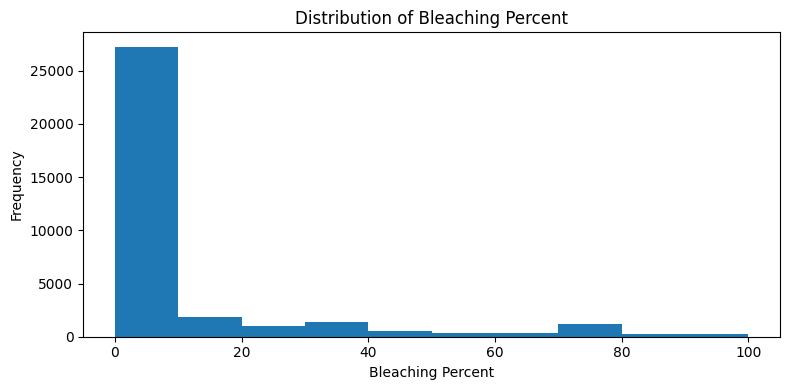

In [16]:
# checking target distribution and class imbalance
plt.figure(figsize=(8,4))
plt.hist(df_supervised['percent_bleaching'], bins=10)

plt.xlabel('Bleaching Percent')
plt.ylabel('Frequency')
plt.title('Distribution of Bleaching Percent') 
plt.tight_layout()
plt.show()

The distribution is severely zero-inflated and right-skewed with 48.2% of observations being 0. Nearly half of our dataset recorded no bleaching at all. Median is 0.25%, meaning more than half the dataset is "no bleaching". Mean is 9.6% but std is 20.2%, the mean is being pulled hard by a long right tail. 75th percentile is only 6%, so 75% of data has less than 6% bleaching.

I did some research on percent_cover, bleaching_level (dropped earlier) and percent_bleaching by reading documentation on each : https://www.bco-dmo.org/dataset/773466
- **percent_cover** : measures how much substrate space a species occupies. It's about relative abundance of organisms on the reef floor. But its different from percent_bleaching. E.g. A reef could have 80% coral cover (lots of coral)  30% bleaching (30% of that coral is bleached). So, they're independent measurements.
- **substrate_name** -type of substrate from Reef Check data. Missing: 12047 (35%); Distinct: 3
    - Hard Coral - 33%
    - Nutrient Indicator Algae - 32%
    - Fleshy Seaweed - <1%
- **bleaching_level** is not useful for imputation, it's just a site-level descriptor with one value.
- **percent_bleaching** - is an average of four transect segments (Reef Check) or average of a bleaching code. Need to check the data collection method for precent_bleaching.

``It is possible that data was collected overtime, sites may have been surveyed for physical/environmental parameters first, with biological assessments (bleaching) added in a later expedition. This would produce rows with complete feature data but missing percent_bleaching.``

``Its worth checking if the same site was surveyed multiple times across years, as that would result in duplicate rows.``


In [17]:
# df_supervised
# Check for duplicate rows
print(f"Total rows: {len(df_supervised)}")
print(f"Fully duplicate rows: {df_supervised.duplicated().sum()}")

# Check for duplicate sites with same location (lat/ long) but different dates
location_date_dupes = df_supervised.duplicated(
    subset=['latitude_degrees', 'longitude_degrees', 'date'], 
    keep=False
)
print(f"Same location + date duplicates: {location_date_dupes.sum()}")

# How many unique sites?
unique_sites = df_supervised.groupby(['latitude_degrees', 'longitude_degrees']).size().reset_index(name='survey_count')

print(f"\nUnique lat/long locations: {len(unique_sites)}")
print(f"Sites surveyed more than once:")
print(unique_sites['survey_count'].value_counts().head(10))

Total rows: 34515
Fully duplicate rows: 47
Same location + date duplicates: 27729

Unique lat/long locations: 10847
Sites surveyed more than once:
survey_count
1     5696
2     2165
4     1110
6      360
8      292
3      170
12     165
10     160
5      128
7       92
Name: count, dtype: int64


#### Observations:
1. **percent_bleaching** is a site level average. So, the zero-inflation (48.2% zeros) means at those sites/times, no bleaching was observed across all transects.
2. The data is pooled from 7 different sources, The documentation states "compared coordinates to ensure a sampling event was not duplicated across multiple data sources". Yet, we found 27,729 rows with same location+date. Likely they ran differnt survey methods at the same site on the same date. These are separate observations that may capture different aspects of the same reef.
3. **Panel data**: we have 10,847 unique locations, but many were surveyed multiple times.
4. **Zero-inflation**: how to handle?
5. **What's our Modelling Goal** : 
        bleaching or no bleaching? 
        severity of bleaching - risk classification?
        when extreme events occur - long tail?

#### Industry approach for Zero-Inflated Targets: Two-Model (Hurdle) Approach
This is often preferred in industry because it's interpretable and flexible:
- Model 1 (Classifier) : Predicts whether any bleaching occurs (binary: 0 vs >0)
- Model 2 (Regressor) : Predicts the severity only on cases where bleaching occurs

#### How to address Panel data:
**Option A: Ignore the Panel Structure**

Many industry applications treat each observation as independent and:
- Use cross-validation that respects temporal order (no future data leaking into training)
- Add time-based features (year, month, days since last bleaching event)
- If predictions are for new sites/times, not forecasting existing sites, this can be acceptable

**Option B: Aggregation**
- Average multiple surveys at same site-date into one observation
- This simplifies to a repeated-measures structure without the same-date duplicates
- Each site then has a time series of observations

**Option C: Use mixed-effects/hierarchical models that include**
- Random intercepts per site (each reef has its own baseline bleaching tendency)
- Temporal autocorrelation structures (bleaching in 2016 predicts bleaching in 2017)
- Year fixed effects (global thermal stress events affect all sites)

In [18]:
# checking distribution of non zero bleaching obervations
non_zero = df_supervised[df_supervised['percent_bleaching'] > 0]
print(non_zero['percent_bleaching'].describe())
print(f"Skewness: {non_zero['percent_bleaching'].skew()}")

count    17886.000000
mean        18.562889
std         24.913748
min          0.010000
25%          1.750000
50%          5.500000
75%         28.280000
max        100.000000
Name: percent_bleaching, dtype: float64
Skewness: 1.5912745512669788


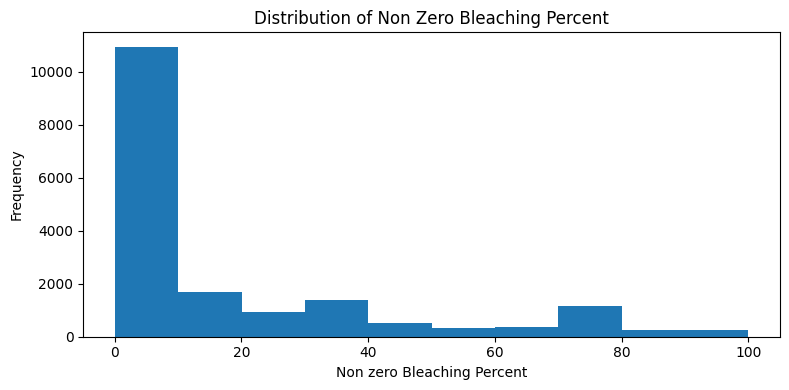

In [19]:
# checking non-zero distribution 
plt.figure(figsize=(8,4))
plt.hist(non_zero['percent_bleaching'], bins=10)

plt.xlabel('Non zero Bleaching Percent')
plt.ylabel('Frequency')
plt.title('Distribution of Non Zero Bleaching Percent') 
plt.tight_layout()
plt.show()

1. Drop the 47 fully duplicated rows so Our data represents true separate samples. This will handle the same‑site‑same‑Date Row problem effectively.
2. We decided not to go ahead with binary classifier as our baseline model, Instead use Multiclass Classification using NOAA style bins.
https://www.aims.gov.au/research-topics/environmental-issues/coral-bleaching/coral-bleaching-events
3. Create classification bins and check their distribution
4. We will use mixed effects to handle the time series component. For baseline we can include year as a feature. We will not drop years even though the data is unbalanced. For train-test split we can train on 2016 and test on 2017.

Export the df_supervised to a csv and continuing feature engineering and modelling there.

In [20]:
# 1. Drop the 47 fully duplicated rows
df_supervised = df_supervised.drop_duplicates().copy()
df_supervised.shape

(34468, 37)

We have the following options for the multiclass classification - baseline model:
1. We could use multiclass logistic regression with class_weight = balanced. So, the minority classes get larger weights, and the majority class gets smaller weights. This would use all the data. Model can still predict larger class, but it could be a good baseline to begin with.
2. We could randomly undersample the low category and draw random samples from other 2 categories, but we lose a lot of data and we will be left with ~9000 - 11000 rows.
3. We could use quantile based bins that handle the class imbalance, but its not scientifically meaningful for ecological purposes.

We choose - multiclass logistic regression with class_weight = balanced, df = df_supervised

In [21]:
# Add year as feature
df_supervised['year'] = pd.to_datetime(df_supervised['date']).dt.year

In [22]:
# Shape of dataframe
print(f"Shape of df_supervised: {df_supervised.shape}")
df_supervised.head()

Shape of df_supervised: (34468, 38)


,latitude_degrees,longitude_degrees,distance_to_shore,exposure,turbidity,cyclone_frequency,depth_m,substrate_name,percent_cover,percent_bleaching,...,tsa_frequency,tsa_frequency_standard_deviation,tsa_frequencymax,tsa_frequencymean,tsa_dhw,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean,date,year
0,23.163,-82.5260,8519.23,Exposed,0.0287,49.90,10.00,NaN,NaN,50.2,...,0.00,1.09,5.0,0.0,0.00,0.74,7.25,0.18,2005-09-15,2005
1,-17.575,-149.7833,1431.62,Exposed,0.0262,51.20,14.00,NaN,NaN,50.7,...,0.25,0.93,4.0,0.0,0.26,0.67,4.65,0.19,1991-03-15,1991
2,18.369,-64.5640,182.33,Exposed,0.0429,61.52,7.00,NaN,NaN,50.9,...,7.00,1.31,7.0,0.0,0.00,1.04,11.66,0.26,2006-01-15,2006
3,17.760,-64.5680,313.13,Exposed,0.0424,65.39,9.02,NaN,NaN,50.9,...,3.00,0.94,4.0,0.0,0.00,0.75,5.64,0.20,2006-04-15,2006
4,17.769,-64.5830,792.00,Exposed,0.0424,65.39,12.50,NaN,NaN,50.9,...,3.00,1.33,5.0,0.0,0.00,0.92,6.89,0.25,2006-04-15,2006


In [23]:
# # Export to csv for modelling
df_supervised.to_csv('bco_supervised_clean.csv', index=False)

In [24]:
print(f"Unique values in df_sup columns:\n{df_supervised.nunique().sort_values().head(10)}")
print(f"\nNAN values in df_sup columns:\n{df_supervised.isna().sum().sort_values(ascending=False).head()}")

Unique values in df_sup columns:
exposure                     3
substrate_name               3
windspeed                   18
year                        36
tsa_frequencymean           72
ssta_standard_deviation    120
ssta_frequencymean         147
tsa_frequency              197
tsa_frequencymax           216
tsa_dhwmean                232
dtype: int64

NAN values in df_sup columns:
substrate_name    12015
percent_cover     11810
depth_m            1679
ssta                122
ssta_dhw            122
dtype: int64


percent_cover and substrate_name have lot of nan's. 
<br>Percent cover is a method of determining relative abundance of a plant or sessile animal based on the amount of space they occupy within a plot of substrate. In this method, rather than counting the number of individuals, each species is assigned a percent cover based on a visual estimate of how much of the sample plot they occupy. So percent_cover depends on substrate, its not missing at random and cannot be imputed. It could be dropped as a feature as its not meaningful for prediction.
<br> substrate_name also cannot be imputed as we don’t know whether missing substrate_name means “no substrate observed”, “not recorded”, etc. But its useful as a feature so we will fill the nan's with the value 'unknown' 

In [25]:
# Its ok to fill nan with 'unknown' for this feature column as it is a categorical label, 
# so there is no risk of data leakage.
df_supervised['substrate_name'] = df_supervised['substrate_name'].fillna('unknown')

#### Bleaching Class Definition 
Target Variable: Bleaching Class Redefinition
The original binning strategy used three classes: Low (0–10%), Medium (11–30%), and High (31–100%). While intuitive, this resulted in a severely imbalanced class distribution. Class 1 had the lowest samples, making it the hardest class to learn. 
- class 0 : Low : 27666, 80.3%
- class 1 : Medium : 2525, 7.3%
- class 2 : High : 4277, 12.4%

Upon further research, we updated the bleaching classification bins to shift the low threshold from 10% to 1%. The rationale behind this approach is to separate reefs with negligible bleaching from stressed reefs. The medium category is a better representation of reefs under moderate thermal stress and shows the ecologically critical early-warning zone. High category is the same, showing severely bleached reefs requiring intervention. As shown below class 1 has increased to ~10k smaples from ~2k samples. While the class imbalance still persists, it has improved as compared to the previous approach.
- class 0 : Low : 19926, 57.8% 
- class 1 : Medium : 10265, 29.8%
- class 2 : High : 4277, 12.4%

In [26]:
# Redefine target variable
# Bleaching class
# <= 10 Low
# 11 - 30 Medium
# 31 High
bins = [-0.01, 1, 30, 100]

labels = [0, 1, 2]  # 0=low, 1=medium, 2=high

df_supervised['bleaching_class'] = pd.cut(
    df_supervised['percent_bleaching'],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

# check the target's class distribution
print(df_supervised['bleaching_class'].value_counts().sort_index())
# print(df_supervised.groupby('bleaching_class').size())
print(df_supervised['bleaching_class'].value_counts(normalize=True).round(3).sort_index())

bleaching_class
0    19926
1    10265
2     4277
Name: count, dtype: int64
bleaching_class
0    0.578
1    0.298
2    0.124
Name: proportion, dtype: float64


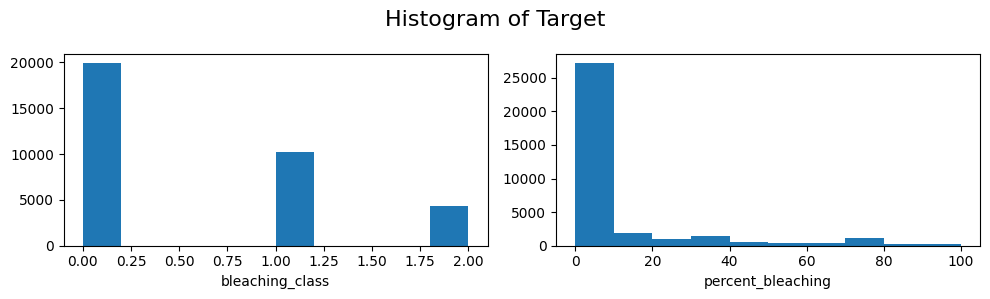

In [27]:
# Histogram of Bleaching Target
columns = ['bleaching_class', 'percent_bleaching']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
for idx, ax in enumerate(axes.flatten()):
    # plot histogram
    ax.hist(df_supervised[columns[idx]])
    # set xlabel
    ax.set_xlabel(columns[idx])


fig.suptitle("Histogram of Target", fontsize=16)
plt.tight_layout()
plt.show()

#### Define X,y variable followed by data splits

In [28]:
# drop percent bleaching as that's part of how the target class was created
# Drop columns not used in modelling
df_supervised = df_supervised.drop(columns=['percent_bleaching', 'date', 'percent_cover'], errors='ignore')

## Identify feature columns
feature_cols = [col for col in df_supervised.columns if col != 'bleaching_class']

# Define X and y variables
X = df_supervised[feature_cols]
y = df_supervised['bleaching_class']

The dataset is split into training (60%), validation (20%), and test (20%) sets using stratify=y to preserve the class distribution across all splits. Stratification is important here given the class imbalance. Without it, minority classes could be underrepresented in the validation or test sets, producing unreliable evaluation metrics.

- X_train / y_train used exclusively for model fitting and feature analysis
- X_val / y_val used for hyperparameter decisions and model comparison during development
- X_test / y_test held out entirely; used only for final evaluation

All correlation and VIF analysis is performed on the training set only to prevent data leakage.

We will not scale/ transform the training data before modelling. We will apply the scaling/encoding inside each model's pipeline, fit the preprocessing only on the training fold and let  the pipeline transform validation/test automatically.  
- Logistic Regression: inside pipeline with standard scaler
- Random Forest: does not need scaling. Tree-based models are invariant to monotonic transformations.
- Gradient Boosted Trees: no scaling needed.
- SVM, KNN, Neural Nets: scaling handled in their own pipelines.

Similarly, we will not compute class weights before modeling and handle class imbalance inside each model. 
- Logistic Regression uses class_weight='balanced'
- Random Forest can use class_weight='balanced' or custom weights
- Gradient Boosted Trees may use scale_pos_weight or sample weighting
- Some models ignore class weights entirely

In [29]:
# Data Split 60:20:20

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

 # Shape of each dataframe
print('Size of X_train', X_train.shape)
print('Size of Y_train', y_train.shape)
print('Size of X_val', X_val.shape)
print('Size of Y_val', y_val.shape)
print('Size of X_test', X_test.shape)
print('Size of Y_test', y_test.shape)

Size of X_train (20680, 35)
Size of Y_train (20680,)
Size of X_val (6894, 35)
Size of Y_val (6894,)
Size of X_test (6894, 35)
Size of Y_test (6894,)


In [30]:
# df for y_train and X_train
df_train = pd.concat([pd.DataFrame(y_train), pd.DataFrame(X_train)], axis=1)

In [31]:
df_train.columns

Index(['bleaching_class', 'latitude_degrees', 'longitude_degrees',
       'distance_to_shore', 'exposure', 'turbidity', 'cyclone_frequency',
       'depth_m', 'substrate_name', 'climsst', 'temperature_mean',
       'temperature_maximum', 'windspeed', 'ssta', 'ssta_standard_deviation',
       'ssta_maximum', 'ssta_frequency', 'ssta_frequency_standard_deviation',
       'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw',
       'ssta_dhw_standard_deviation', 'ssta_dhwmax', 'ssta_dhwmean', 'tsa',
       'tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency',
       'tsa_frequency_standard_deviation', 'tsa_frequencymax',
       'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation',
       'tsa_dhwmax', 'tsa_dhwmean', 'year'],
      dtype='object')

Given the large number of features in the dataset, we grouped the features for the ease of plotting and analysis.

In [32]:
# group feature columns for analysis
feature_groups = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'], #4
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw', 'tsa_dhw'], #5
'ssta_family': [ 'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency', #9
       'ssta_frequency_standard_deviation', 'ssta_frequencymax',
       'ssta_frequencymean', 'ssta_dhw_standard_deviation', 'ssta_dhwmax', 
       'ssta_dhwmean'],
'tsa_family': ['tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency', #9
       'tsa_frequency_standard_deviation', 'tsa_frequencymax', 'tsa_frequencymean', 
       'tsa_dhw_standard_deviation', 'tsa_dhwmax', 'tsa_dhwmean'],
'environmental': ['temperature_mean', 'temperature_maximum', 'windspeed', 'turbidity', #5
                  'cyclone_frequency'],
# 'categorical': ['exposure', 'substrate_name'], #2
'temporal': ['year'], #1
}

In [33]:
# Numeric columns for correlation matrix
numeric_cols = df_train[feature_cols].select_dtypes(include=['int64', 'float64']).columns

#### Feature Selection - For Baseline Logistic Regression Model
To build a stable and interpretable Logistic Regression baseline, we first examine feature-target and feature-feature correlations. Any features with correlation above 0.4 are removed to reduce redundancy and multicollinearity. From the remaining set, we calculate VIF scores and exclude features with VIF values greater than 10.

#### Correlation Matrices:
The previous implementation uses the default .corrwith() method, which computes Pearson correlation. We decided to switch to Spearman rank correlation due to the following reasons:
1. bleaching_class is an ordinal encoded integer (0, 1, 2), not a continuous variable. Pearson assumes a linear relationship between continuous variables and applying it to an ordinal target introduces assumptions that don't hold.
2. Several features (e.g. ssta_dhw, depth_m) are right-skewed, violating Pearson's normality assumption. (As per histograms plotted in the BCO_Final_Preprocessing_EDA.ipynb notebook.)
3. Spearman correlation measures monotonic relationships without assuming linearity or normality, making it better suited for ordinal targets and skewed distributions.

In [34]:
# Correlations with Target
for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 0:
        print(f"\n=== {group_name.upper()} vs TARGET ===")
        corr_vals = df_train[numeric_group_cols].corrwith(df_train['bleaching_class'], method='spearman')
        display(corr_vals.sort_values(ascending=False))


=== SPATIAL vs TARGET ===


distance_to_shore    0.274619
latitude_degrees     0.154271
depth_m              0.142185
longitude_degrees   -0.241851
dtype: float64


=== THERMAL_BASELINE vs TARGET ===


tsa_dhw     0.280813
ssta_dhw    0.189257
tsa         0.161234
ssta        0.100274
climsst    -0.081174
dtype: float64


=== SSTA_FAMILY vs TARGET ===


ssta_standard_deviation              0.256645
ssta_frequency                       0.090944
ssta_maximum                        -0.032245
ssta_frequencymean                  -0.158806
ssta_dhwmean                        -0.159911
ssta_dhwmax                         -0.167921
ssta_frequencymax                   -0.174294
ssta_dhw_standard_deviation         -0.182979
ssta_frequency_standard_deviation   -0.224900
dtype: float64


=== TSA_FAMILY vs TARGET ===


tsa_frequency                       0.141591
tsa_standard_deviation              0.096931
tsa_maximum                        -0.053008
tsa_dhwmax                         -0.140702
tsa_dhw_standard_deviation         -0.190056
tsa_dhwmean                        -0.207866
tsa_frequencymax                   -0.217011
tsa_frequencymean                  -0.230280
tsa_frequency_standard_deviation   -0.236161
dtype: float64


=== ENVIRONMENTAL vs TARGET ===


windspeed              0.057203
cyclone_frequency      0.056930
turbidity             -0.039615
temperature_maximum   -0.047230
temperature_mean      -0.165117
dtype: float64

#### I. Correlation results with target:

1. Spatial - weak correlations overall - spatial gradients are not strong predictors of bleaching, they are safe to keep, but they won’t dominate prediction. depth_m (0.14) - `keep`

2. Thermal Baseline - Bleaching is overwhelmingly driven by thermal stress. DHW metrics (ssta_dhw, tsa_dhw) are good predictors so far. DHW (Degree Heating Weeks) variables show the most meaningful relationship with the target as accumulated heat stress is the primary driver of bleaching.
    - **tsa** (0.16) and **ssta** (0.10)
    - **tsa_dhw** (0.28) and **ssta_dhw** (0.255) `keep`, highly correlated with each other - need only 1 of these, but we can keep both for tree‑based models.  

3. SSTA family - This group is highly redundant, and only two features show mild positive correlation
    
    - **ssta_standard_deviation** (0.257) `keep`
    - **ssta_frequency** (0.09) - `keep`
    - **ssta_maximum** (0.003) - `Drop`
    - Most **dhwmean**, **dhw_standard_deviation**, **dhwmax**  (all near zero or negative) `Drop`        

4. TSA family - 
    - **tsa_frequency** (0.149) - `keep` mildly predictive
    - **tsa_maximum** (0.003) - `Drop`
    - everything else is redundant

5. Environment - no meaningful correlation
        - **windspeed** (0.05), **cyclone_frequency** (0.024) - `Drop`
        - **turbidity** (-0.04), **temperature_mean** (-0.077) - `Drop`
        - **temperature_mean** (-0.17) - `keep'

6. Temporal - Bleaching severity decreases slightly over time. sampling bias? recovery?
        - **year** (-0.23) — Moderate negative correlation suggests a temporal trend. 


Given the large number of features in the dataset, we applied a correlation threshold of |r| > 0.4 to surface only the most meaningful relationships within each feature group. This will help reduce noise from weak or incidental correlations and highlights pairs of variables that may contribute redundant information or multicollinearity. <br>
We use the default - Pearson correlation here since the goal is to identify linear dependencies among features within each group.

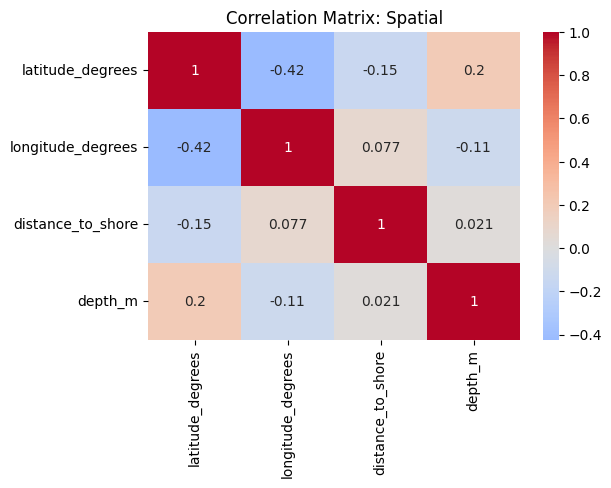

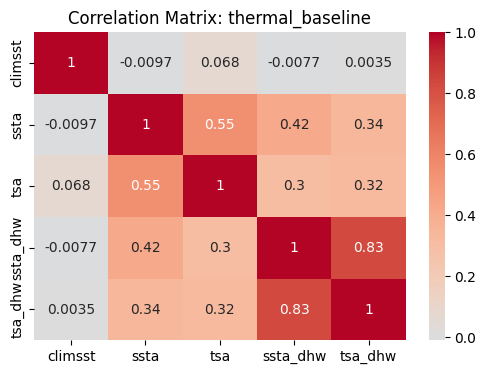

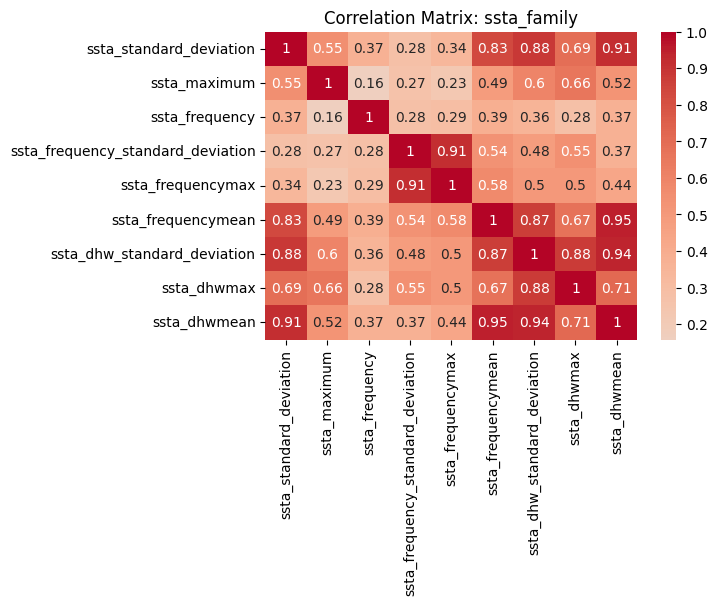

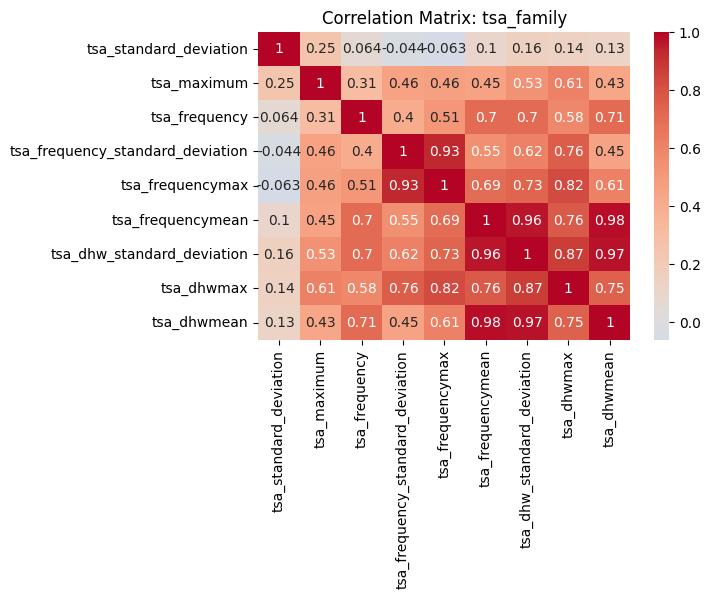

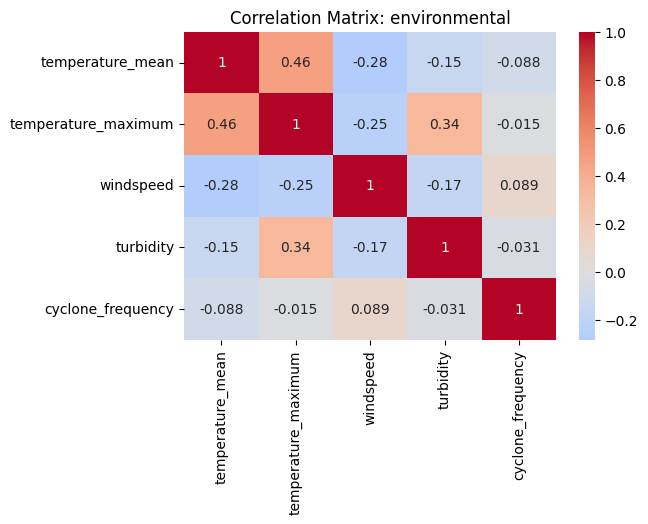

In [35]:
# Correlation between feature groups to check for multicolinearity

for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 1:
        plt.figure(figsize=(6, 4))
        sns.heatmap(df_train[numeric_group_cols].corr(), annot=True, cmap='coolwarm', center=0)
        plt.title(f"Correlation Matrix: {group_name}")
        plt.show()


In [36]:
threshold = 0.4

for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 1:
        corr = df_train[numeric_group_cols].corr()
        filtered = corr[(corr.abs() > threshold) & (corr.abs() != 1)]
        
        print(f"\n=== {group_name.upper()} (|r| > {threshold}) ===")
        display(filtered)


=== SPATIAL (|r| > 0.4) ===


,latitude_degrees,longitude_degrees,distance_to_shore,depth_m
latitude_degrees,NaN,-0.42498,NaN,NaN
longitude_degrees,-0.42498,NaN,NaN,NaN
distance_to_shore,NaN,NaN,NaN,NaN
depth_m,NaN,NaN,NaN,NaN



=== THERMAL_BASELINE (|r| > 0.4) ===


,climsst,ssta,tsa,ssta_dhw,tsa_dhw
climsst,NaN,NaN,NaN,NaN,NaN
ssta,NaN,NaN,0.549319,0.419266,NaN
tsa,NaN,0.549319,NaN,NaN,NaN
ssta_dhw,NaN,0.419266,NaN,NaN,0.83431
tsa_dhw,NaN,NaN,NaN,0.834310,NaN



=== SSTA_FAMILY (|r| > 0.4) ===


,ssta_standard_deviation,ssta_maximum,ssta_frequency,ssta_frequency_standard_deviation,ssta_frequencymax,ssta_frequencymean,ssta_dhw_standard_deviation,ssta_dhwmax,ssta_dhwmean
ssta_standard_deviation,NaN,0.548409,NaN,NaN,NaN,0.834415,0.882311,0.690767,0.913682
ssta_maximum,0.548409,NaN,NaN,NaN,NaN,0.485061,0.597347,0.662705,0.523179
ssta_frequency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ssta_frequency_standard_deviation,NaN,NaN,NaN,NaN,0.911448,0.535637,0.479997,0.545925,NaN
ssta_frequencymax,NaN,NaN,NaN,0.911448,NaN,0.575182,0.501170,0.503272,0.436081
ssta_frequencymean,0.834415,0.485061,NaN,0.535637,0.575182,NaN,0.870485,0.671795,0.946775
ssta_dhw_standard_deviation,0.882311,0.597347,NaN,0.479997,0.501170,0.870485,NaN,0.877489,0.943430
ssta_dhwmax,0.690767,0.662705,NaN,0.545925,0.503272,0.671795,0.877489,NaN,0.714905
ssta_dhwmean,0.913682,0.523179,NaN,NaN,0.436081,0.946775,0.943430,0.714905,NaN



=== TSA_FAMILY (|r| > 0.4) ===


,tsa_standard_deviation,tsa_maximum,tsa_frequency,tsa_frequency_standard_deviation,tsa_frequencymax,tsa_frequencymean,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean
tsa_standard_deviation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tsa_maximum,NaN,NaN,NaN,0.457914,0.461302,0.452921,0.534843,0.610100,0.434372
tsa_frequency,NaN,NaN,NaN,NaN,0.507241,0.704434,0.703407,0.577559,0.706691
tsa_frequency_standard_deviation,NaN,0.457914,NaN,NaN,0.930798,0.551566,0.615703,0.758284,0.450484
tsa_frequencymax,NaN,0.461302,0.507241,0.930798,NaN,0.693239,0.733624,0.818698,0.614836
tsa_frequencymean,NaN,0.452921,0.704434,0.551566,0.693239,NaN,0.961732,0.763572,0.975601
tsa_dhw_standard_deviation,NaN,0.534843,0.703407,0.615703,0.733624,0.961732,NaN,0.868121,0.969534
tsa_dhwmax,NaN,0.610100,0.577559,0.758284,0.818698,0.763572,0.868121,NaN,0.745408
tsa_dhwmean,NaN,0.434372,0.706691,0.450484,0.614836,0.975601,0.969534,0.745408,NaN



=== ENVIRONMENTAL (|r| > 0.4) ===


,temperature_mean,temperature_maximum,windspeed,turbidity,cyclone_frequency
temperature_mean,NaN,0.462734,NaN,NaN,NaN
temperature_maximum,0.462734,NaN,NaN,NaN,NaN
windspeed,NaN,NaN,NaN,NaN,NaN
turbidity,NaN,NaN,NaN,NaN,NaN
cyclone_frequency,NaN,NaN,NaN,NaN,NaN


#### I. Feature correlation results:

1. Spatial - light correlations overall.  - `keep all`

2. Thermal Baseline - Bleaching is overwhelmingly driven by thermal stress. DHW metrics (ssta_dhw, tsa_dhw) are good predictors so far. DHW (Degree Heating Weeks) variables show the most meaningful relationship with the target as accumulated heat stress is the primary driver of bleaching. SSTA and TSA track similar thermal anomalies. DHW metrics are derived from anomalies, so they cluster.
    - **tsa** and **ssta** (0.55) - `keep`
    - **ssta** and **ssta_dhw** (0.41) - `keep`
    - **tsa_dhw** and **ssta_dhw** (0.82) `keep`, highly correlated with each other - need only 1 of these, but we can keep both for tree‑based models.

3. SSTA family - This group has extremely high correlations. classic multicollinearity - features are all derived from the same underlying SST anomaly time series. Run PCA to select features? PCA? dimensionality reduction? or similar to target correlations -
    
    - **ssta_standard_deviation**  `keep`
    - **ssta_frequency**  - `keep`
    - **ssta_maximum** - `Drop`
    - Most **dhwmean**, **dhw_standard_deviation**, **dhwmax**  `Drop`        

4. TSA family - mirrors the SSTA family because TSA is a parallel anomaly metric. Group is internally redundant. PCA? dimensionality reduction? or similar to target correlations -
    - **tsa_frequency** - `keep`
    - **tsa_maximum**  - `Drop`
    - everything else is redundant

5. Environment - Only one moderate correlation
        - **temperature_max** and **temperature_mean** (0.45) - `Drop`  

#### Modelling continued in Notebook - 02_bco_supervised_ml_models

I will save splits using joblib, so they can be cleanly imported in the modelling notebook. This is an industry standard way for clear data flow and reproducibility.

In [37]:
numeric_features = ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 
                    'turbidity', 'cyclone_frequency', 'depth_m', 'climsst',  
                    'temperature_mean', 'temperature_maximum', 'windspeed', 'ssta', 
                    'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency', 
                    'ssta_frequency_standard_deviation', 'ssta_frequencymax', 
                    'ssta_frequencymean', 'ssta_dhw', 'ssta_dhw_standard_deviation', 
                    'ssta_dhwmax', 'ssta_dhwmean', 'tsa', 'tsa_standard_deviation', 
                    'tsa_maximum', 'tsa_frequency', 'tsa_frequency_standard_deviation', 
                    'tsa_frequencymax', 'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation',
                    'tsa_dhwmax', 'tsa_dhwmean', 'year']
categorical_features = ['exposure', 'substrate_name',]

In [39]:
import joblib, os

os.makedirs('artifacts', exist_ok=True)

joblib.dump({
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'feature_cols': feature_cols,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'feature_groups': feature_groups
}, 'artifacts/data_splits.pkl')

print(f"Saved splits: {X_train.shape, X_val.shape, X_test.shape} \n{y_train.shape, y_val.shape, y_test.shape}")

Saved splits: ((20680, 35), (6894, 35), (6894, 35)) 
((20680,), (6894,), (6894,))
